# Mie Particle Position Optimization with PyTorch Autodifferentiation

This notebook fits the `(x, y)` position of a single `MieSphere` by backpropagating through a `Brightfield` image. We use fixed `L`, `collection_angle`, and `offset_z` so the optimized variables are continuous.

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from deeptrack.backend import config
from deeptrack.optical.optics import Brightfield
from deeptrack.optical import scatterers

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)
torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cpu')

Create a particle at known position `(x, y)` as the target ground truth.

In [7]:
true_x, true_y = 15.5, 17.25

with config.with_backend("torch"):
    optics = Brightfield(
        NA=0.7,
        wavelength=680e-9,
        refractive_index_medium=1.33,
        resolution=1e-6,
        magnification=10,
        output_region=(0, 0, 32, 32),
        padding=(4, 4, 4, 4),
    )

    mie_kwargs = dict(
        radius=0.5e-6,
        refractive_index=1.45,
        position_unit="pixel",
        input_polarization=0.0,
        output_polarization=0.0,
        L=5,
        collection_angle=0.3,
        offset_z=1e-5,
        mode="hybrid",
    )

    target_sample = scatterers.MieSphere(
        position=(true_x, true_y),
        **mie_kwargs,
    )
    target = optics(target_sample).update()().detach()

Create the variables to optimize as torch tensors with `requires_grad=True`. This allows PyTorch to compute gradients with respect to these variables during backpropagation.

DeepTrack caches feature outputs, so we need to call `update()` after each optimizer step.

In [8]:
with config.with_backend("torch"):
    x = torch.tensor(13.0, requires_grad=True)
    y = torch.tensor(14.5, requires_grad=True)

    fitted_sample = scatterers.MieSphere(
        position=(x, y),
        **mie_kwargs,
    )
    pipeline = optics(fitted_sample)
    optimizer = torch.optim.Adam([x, y], lr=0.2)

    history = []
    for step in range(50):
        optimizer.zero_grad()
        image = pipeline.update()()
        loss = ((image - target) ** 2).mean()
        loss.backward()
        optimizer.step()

        history.append(
            (step, loss.item(), x.detach().item(), y.detach().item())
        )

history = np.array(history)
print(f"true position:   ({true_x:.2f}, {true_y:.2f})")
print(f"fitted position: ({history[-1, 2]:.2f}, {history[-1, 3]:.2f})")
print(f"final loss:      {history[-1, 1]:.3e}")

true position:   (15.50, 17.25)
fitted position: (15.42, 17.09)
final loss:      6.102e-06


Plot the loss and the position history.

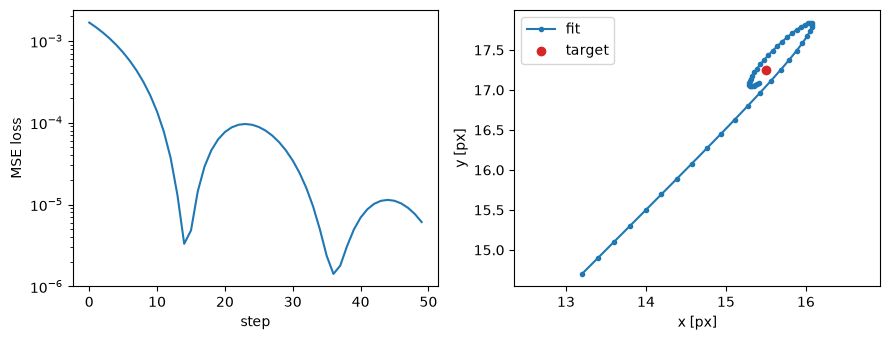

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].semilogy(history[:, 0], history[:, 1])
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")

axes[1].plot(history[:, 2], history[:, 3], marker=".", label="fit")
axes[1].scatter([true_x], [true_y], c="tab:red", label="target")
axes[1].set_xlabel("x [px]")
axes[1].set_ylabel("y [px]")
axes[1].axis("equal")
axes[1].legend()

fig.tight_layout()

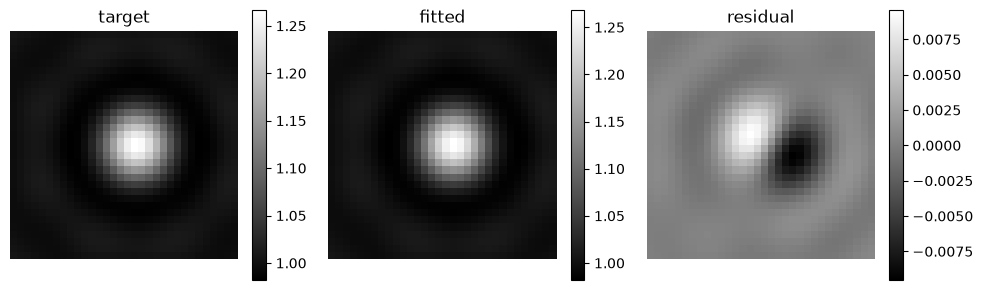

In [12]:
fitted_image = pipeline.update()().detach()
residual = fitted_image - target

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, array, title in zip(
    axes,
    (target, fitted_image, residual),
    ("target", "fitted", "residual"),
):
    ax.imshow(array[..., 0].cpu().numpy(), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
    # Colorbar
    plt.colorbar(ax.images[0], ax=ax)

fig.tight_layout()